In [16]:
import os
import numpy as np
import pandas as pd
import scipy
import glob
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')
# sns.set_theme(style='white')

In [17]:
class KuramotoModel(Dataset):
    def __init__(self, sz, groups, batch_size, time_steps, dt, sample_interval, 
                 intra_coupling_strength, inter_coupling_strength, noise_level, use_cache=True):
        """
        Initialize the Kuramoto model dataset.
        
        :param sz: Total number of oscillators
        :param groups: Number of groups/clusters
        :param batch_size: Number of trajectories to generate
        :param time_steps: Total simulation steps
        :param dt: Integration time step
        :param sample_interval: Sampling interval for storing data
        :param intra_coupling_strength: Scalar or (min, max) range within the same group
        :param inter_coupling_strength: Scalar or (min, max) range between groups
        :param noise_level: Noise intensity
        :param flag: "train", "val", or "test" flag
        """
        self.sz = sz
        self.groups = groups
        self.batch_size = batch_size
        self.time_steps = time_steps
        self.dt = dt
        self.sample_interval = sample_interval
        self.intra_coupling_strength = intra_coupling_strength
        self.inter_coupling_strength = inter_coupling_strength
        self.intra_coupling_range = self._normalize_coupling_range(intra_coupling_strength)
        self.inter_coupling_range = self._normalize_coupling_range(inter_coupling_strength)
        self.noise_level = noise_level
        
        # Initialize Kuramoto model parameters
        self.obj_matrix, self.group_matrix, self.omegas = self.initialize_kuramoto(sz, groups)
        
  
        self.output_data, self.theta_data = self._simulate_multiseries()
        self.time_axis = np.arange(self.output_data.shape[1]) * self.sample_interval * self.dt
            # data_dict = {
            #     'input': self.input,
            #     'output': self.output,
            # }
            # np.save(self.path, data_dict)
    
    def _normalize_coupling_range(self, coupling_strength):
        """Convert a scalar or length-2 iterable into a valid sampling range."""
        if np.isscalar(coupling_strength):
            value = float(coupling_strength)
            return value, value

        if len(coupling_strength) != 2:
            raise ValueError("coupling_strength must be a scalar or a length-2 range.")

        low, high = map(float, coupling_strength)
        if low > high:
            raise ValueError("coupling_strength range must satisfy min <= max.")
        return low, high

    def _sample_symmetric_matrix(self, size, coupling_range):
        """Sample a symmetric coupling matrix from a uniform range."""
        low, high = coupling_range
        if low == high:
            return torch.full([size, size], low, dtype=torch.float32)
        
        upper = torch.empty([size, size], dtype=torch.float32).uniform_(low, high)
        matrix = torch.triu(upper, diagonal=1)
        return matrix + matrix.T
    
    def initialize_kuramoto(self, sz, groups):
        """Initialize Kuramoto model connectivity matrices."""
        obj_matrix = self._sample_symmetric_matrix(sz, self.inter_coupling_range)
        group_matrix = torch.zeros([sz, groups], dtype=torch.float32)
        
        # Build a weighted coupling matrix with sampled intra-group and inter-group strengths.
        base_group_size = sz // groups
        remainder = sz % groups
        start = 0
        for k in range(groups):
            group_size = base_group_size + (1 if k < remainder else 0)
            end = start + group_size
            obj_matrix[start:end, start:end] = self._sample_symmetric_matrix(
                group_size, self.intra_coupling_range
            )
            group_matrix[start:end, k] = 1
            start = end
        obj_matrix.fill_diagonal_(0)
        
        # Natural frequencies
        omegas = torch.randn(sz)
        
        # omegas = torch.empty(sz)
        # base_group_size = sz // groups
        # remainder = sz % groups
        # start = 0
        
        # omega_centers = torch.linspace(-0.6, 0.6, groups)

        # for k in range(groups):
        #     group_size = base_group_size + (1 if k < remainder else 0)
        #     end = start + group_size
        #     omegas[start:end] = omega_centers[k] + 0.05 * torch.randn(group_size)
        #     start = end
    
        return obj_matrix, group_matrix, omegas
    
    def one_step(self, thetas):
        """Perform one integration step of Kuramoto model."""
        ii = thetas.unsqueeze(0).repeat(thetas.size(0), 1)
        jj = ii.transpose(0, 1)
        dff = jj - ii
        sindiff = torch.sin(dff)
        mult = self.obj_matrix @ sindiff
        dia = torch.diagonal(mult, 0) / self.sz
        noise = torch.randn(self.sz) * self.noise_level
        thetas = self.dt * (self.omegas + dia + noise) + thetas
        return thetas
    
    def compute_order_parameters(self, thetas):
        """Compute order parameters (group-level observables)."""
        cos_ccs = (torch.cos(thetas) @ self.group_matrix) * self.groups / self.sz
        sin_ccs = (torch.sin(thetas) @ self.group_matrix) * self.groups / self.sz
        return torch.cat([cos_ccs, sin_ccs], dim=0)
    
    def simulate_oneserie(self):
        """Simulate one trajectory of the Kuramoto model."""
        thetas = torch.rand(self.sz) * 2 * np.pi
        kuramoto_data = []
        theta_history = []
        
        for t in range(self.time_steps):
            thetas = self.one_step(thetas)
            
            if t % self.sample_interval == 0:
                # Current notebook configuration records one feature per oscillator: sin(theta).
                sin_obs = torch.sin(thetas)
                # cos_obs = torch.cos(thetas)
                phase_obs = sin_obs
                # phase_obs = torch.stack((sin_obs, cos_obs), dim=1).reshape(-1)
                # phase_obs = thetas

                # order_params = self.compute_order_parameters(thetas)
                
                # Combine into observation vector (individual phases + group order parameters)
                # obs = torch.cat([phase_obs, order_params])
                kuramoto_data.append(phase_obs.numpy())
                theta_history.append(thetas.numpy())
        
        return np.array(kuramoto_data), np.array(theta_history)

    def _simulate_multiseries(self):
        """Simulate multiple trajectories."""
        num_obs = int(self.time_steps / self.sample_interval)
        # Output dimension: one observed feature per oscillator in the default notebook path.
        output_dim = self.sz
        
        kuramoto_data_all = np.zeros([self.batch_size, num_obs, output_dim])
        theta_data_all = np.zeros([self.batch_size, num_obs, self.sz])
         
        for i in range(self.batch_size):
            phase_obs, theta_history = self.simulate_oneserie()
            kuramoto_data_all[i, :, :] = phase_obs
            theta_data_all[i, :, :] = theta_history
        
        # Reshape into input-output pairs
        # kuramoto_input = kuramoto_data_all[:, :-1, :].reshape(-1, 1, output_dim)
        # kuramoto_output = kuramoto_data_all[:, 1:, :].reshape(-1, 1, output_dim)

        return kuramoto_data_all, theta_data_all

    def _infer_output_layout(self):
        """Infer how many observed features each oscillator contributes."""
        feature_dim = self.output_data.shape[-1]
        if feature_dim == self.sz:
            return 1, False
        if feature_dim == 2 * self.sz:
            return 2, False
        if feature_dim == self.sz + 2 * self.groups:
            return 1, True
        if feature_dim == 2 * self.sz + 2 * self.groups:
            return 2, True
        raise ValueError(
            f'Unsupported output dimension {feature_dim}. Expected sz, 2*sz, sz+2*groups, or 2*sz+2*groups.'
        )

    def get_output_labels(self):
        """Return labels for each observed variable in output_data."""
        features_per_oscillator, include_order_parameters = self._infer_output_layout()
        labels = []
        for i in range(self.sz):
            if features_per_oscillator == 1:
                labels.append(f'sin_theta_{i}')
            else:
                labels.extend([f'sin_theta_{i}', f'cos_theta_{i}'])
        if include_order_parameters:
            labels += [f'cos_group_{i}' for i in range(self.groups)]
            labels += [f'sin_group_{i}' for i in range(self.groups)]
        return labels

    def _get_group_slices(self):
        """Return index ranges for each group."""
        base_group_size = self.sz // self.groups
        remainder = self.sz % self.groups
        group_slices = []
        start = 0
        for group_idx in range(self.groups):
            group_size = base_group_size + (1 if group_idx < remainder else 0)
            end = start + group_size
            group_slices.append((start, end))
            start = end
        return group_slices

    def _get_group_feature_indices(self, start, end):
        """Return feature indices for oscillators within a group."""
        features_per_oscillator, _ = self._infer_output_layout()
        feature_indices = []
        for osc_idx in range(start, end):
            if features_per_oscillator == 1:
                feature_indices.append(osc_idx)
            else:
                feature_indices.extend([2 * osc_idx, 2 * osc_idx + 1])
        return feature_indices

    def plot_output_data(self, sample_idx=0):
        """Plot each group's observed variables in a separate subplot."""
        series = self.output_data[sample_idx]
        labels = self.get_output_labels()
        
        group_slices = self._get_group_slices()

        fig, axes = plt.subplots(self.groups, 1, figsize=(14, 4 * self.groups), sharex=True)
        if self.groups == 1:
            axes = [axes]
        for group_idx, (ax, (start, end)) in enumerate(zip(axes, group_slices)):
            feature_indices = self._get_group_feature_indices(start, end)
            for idx in feature_indices:
                ax.plot(self.time_axis, series[:, idx], linewidth=1.1, alpha=0.85, label=labels[idx])
            ax.set_title(f'Group {group_idx} Output Data Time Series (sample {sample_idx})')
            ax.set_ylabel('Value')
            ax.grid(alpha=0.25)
            ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, fontsize=8)

        axes[-1].set_xlabel('Time')
        plt.tight_layout()
        plt.show()

    def plot_order_parameters(self, sample_idx=0):
        """Plot order parameters averaged over all initial conditions."""
        theta_series_all = self.theta_data
        group_slices = self._get_group_slices()

        global_r_all = np.abs(np.mean(np.exp(1j * theta_series_all), axis=2))
        global_r = np.mean(global_r_all, axis=0)
        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        axes[0].plot(self.time_axis, global_r, color='black', linewidth=2)
        axes[0].set_title('Global Order Parameter R(t) averaged over initial conditions')
        axes[0].set_ylabel('R(t)')
        axes[0].set_ylim(0, 1.05)
        axes[0].grid(alpha=0.25)
        
        for group_idx, (start, end) in enumerate(group_slices):
            group_theta = theta_series_all[:, :, start:end]
            group_r_all = np.abs(np.mean(np.exp(1j * group_theta), axis=2))
            group_r = np.mean(group_r_all, axis=0)
            axes[1].plot(self.time_axis, group_r, linewidth=1.8, alpha=0.9, label=f'Group {group_idx}')

        axes[1].set_title('Group-wise Order Parameters R_g(t) averaged over initial conditions')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('R_g(t)')
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(alpha=0.25)
        axes[1].legend(loc='upper right')
        plt.tight_layout()
        plt.show()
    
    def __len__(self):
        return len(self.output_data)

    def __getitem__(self, idx):
        return idx, torch.tensor(self.output_data[idx], dtype=torch.float32), torch.tensor(self.theta_data[idx], dtype=torch.float32)

In [33]:
model = KuramotoModel(sz=32, groups=2, batch_size=1, time_steps=3000, dt=0.05, sample_interval=1, 
                 intra_coupling_strength=(4, 5), inter_coupling_strength=(-1.0, -0.3), noise_level=0.1)

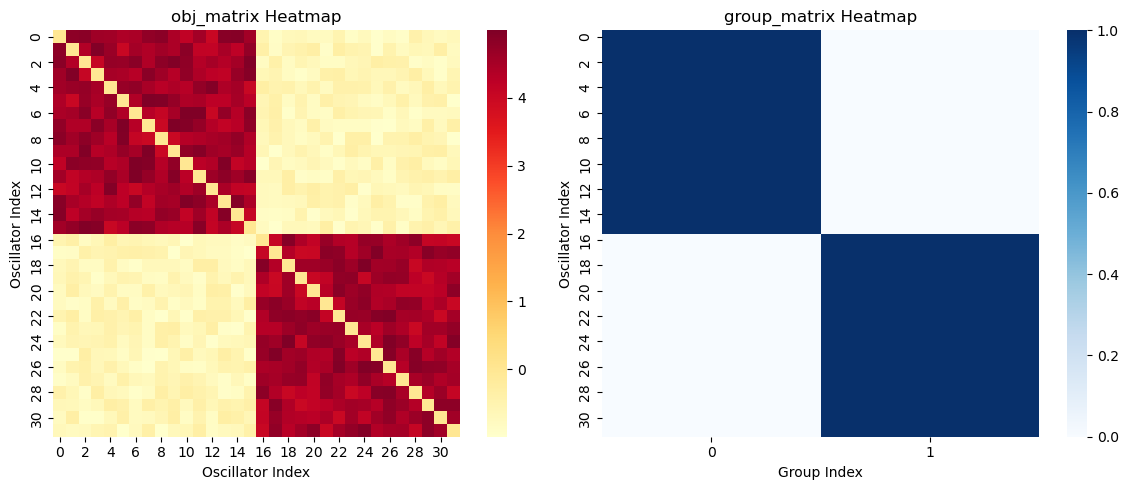

In [34]:
obj_matrix = model.obj_matrix.numpy()
group_matrix = model.group_matrix.numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(obj_matrix, ax=axes[0], cmap='YlOrRd', square=True, cbar=True)
axes[0].set_title('obj_matrix Heatmap')
axes[0].set_xlabel('Oscillator Index')
axes[0].set_ylabel('Oscillator Index')

sns.heatmap(group_matrix, ax=axes[1], cmap='Blues', cbar=True)
axes[1].set_title('group_matrix Heatmap')
axes[1].set_xlabel('Group Index')
axes[1].set_ylabel('Oscillator Index')

plt.tight_layout()
plt.show()

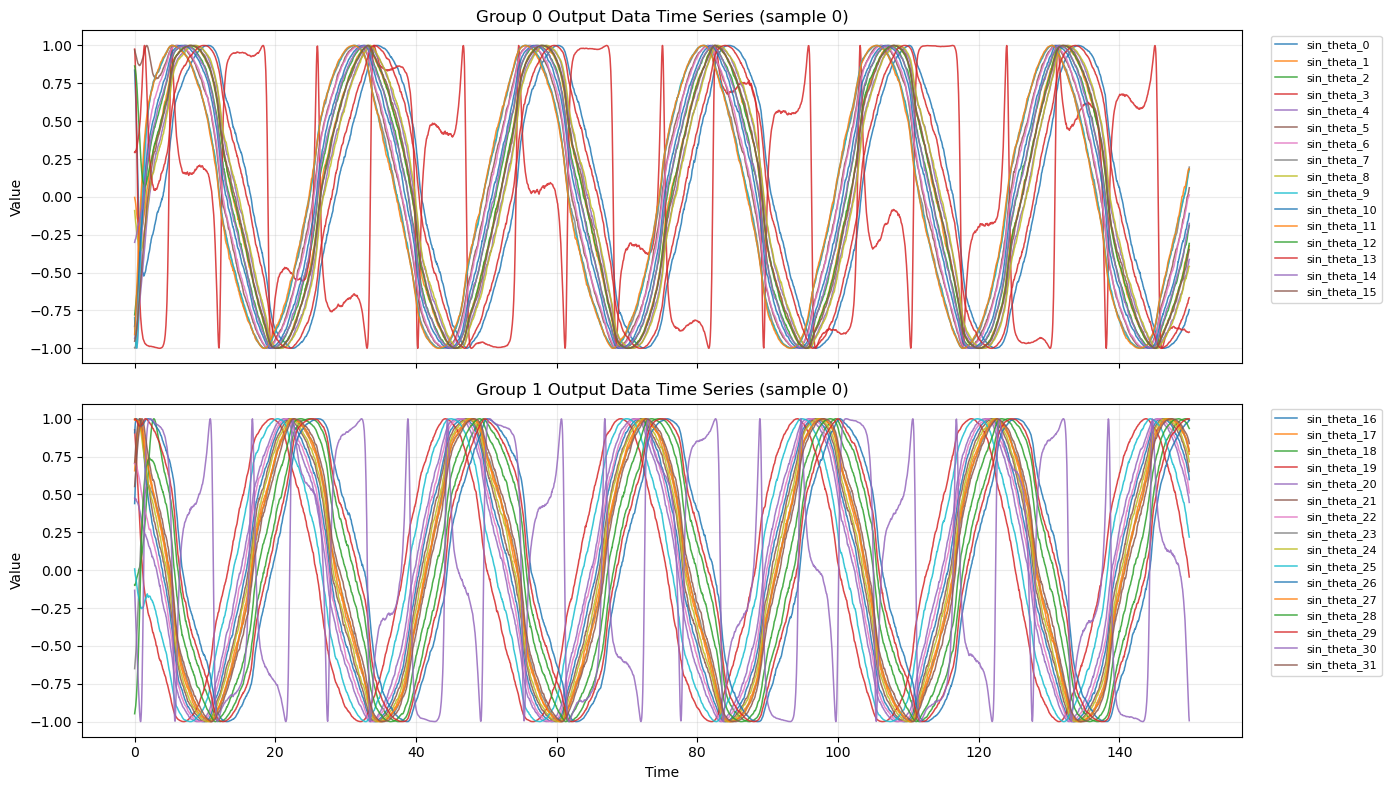

In [35]:
model.plot_output_data(sample_idx=0)

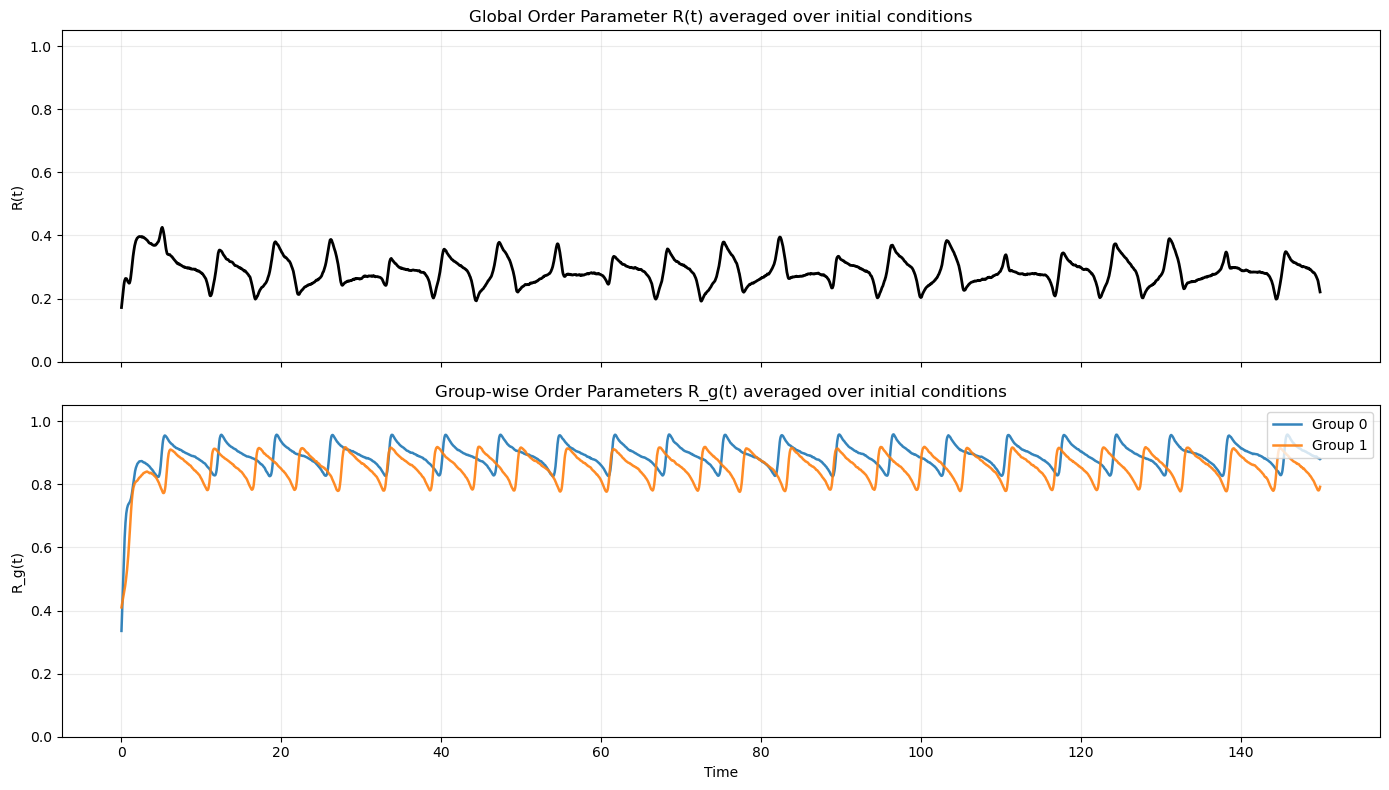

In [36]:
model.plot_order_parameters(sample_idx=0)